# Introducción

El presente análisis tiene como objetivo preparar y explorar los datos históricos de ventas de Más Visión correspondientes al periodo 2022–2024, con la finalidad de construir una base de datos confiable y enriquecida para futuras etapas de visualización y modelado predictivo.

Como parte del proceso, se realizó una validación integral de la calidad de los datos, incluyendo revisión de valores nulos, duplicados, formatos y tipos de variables. Asimismo, se incorporó información adicional relacionada con descuentos mensuales por categoría de producto, permitiendo enriquecer el contexto comercial del análisis.

Posteriormente, se desarrolló un Análisis Exploratorio de Datos (EDA) orientado a identificar tendencias de ventas, patrones estacionales, diferencias entre formatos de sucursal, relaciones entre variables y posibles valores atípicos. Este proceso permitió obtener una comprensión más profunda del comportamiento comercial de la empresa y generar una base sólida para la toma de decisiones basada en datos.

# 1. Cargar y explorar el archivo de datos

In [1]:
# Importar librerías
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

In [11]:
# Cargar el archivo de excel

# Ruta del archivo
archivo = (r'E:\1. Cientifico de Datos\PROYECTOS DE EMPRESAS\EMPRESA +VISION\Etapa 1 Análisis de datos\Etapa 1 - dataexport MV 2022 a 2024.xlsx')

# Cargar hojas
df = pd.read_excel(archivo, sheet_name = 'dataexport')
promo = pd.read_excel(archivo, sheet_name = 'promo', skiprows = 4)

In [4]:
# Explorar el dataset principal
df.head()

,año,mes,Id_suc,Formato,VentaTotal,VentaOftálmico,VentaSolar,VentaLenteContacto,VentaOtros
0,2022,enero,1,E,71.305556,20.118152,16.516133,17.481249,17.190022
1,2022,enero,2,E,67.368188,19.206343,15.918669,16.516939,15.726238
2,2022,enero,3,C,72.135696,20.328936,16.310698,17.666658,17.829404
3,2022,enero,4,E,68.558990,19.237474,16.337713,16.874546,16.109257
4,2022,enero,5,E,66.418809,18.922135,14.614368,16.878948,16.003358


Se visualizan las primeras filas del dataset para comprender la estructura general, los nombres de columnas y los tipos de datos presentes.

In [5]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14831 entries, 0 to 14830
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   año                 14831 non-null  int64  
 1   mes                 14831 non-null  object 
 2   Id_suc              14831 non-null  int64  
 3   Formato             14831 non-null  object 
 4   VentaTotal          14831 non-null  float64
 5   VentaOftálmico      14831 non-null  float64
 6   VentaSolar          14831 non-null  float64
 7   VentaLenteContacto  14831 non-null  float64
 8   VentaOtros          14831 non-null  float64
dtypes: float64(5), int64(2), object(2)
memory usage: 1.0+ MB


Esto ayuda a revisar: Cantidad de registros, Tipos de datos, Valores nulos y Columnas numéricas y categóricas.

In [6]:
# Estadísticas descriptivas
df.describe()

,año,Id_suc,VentaTotal,VentaOftálmico,VentaSolar,VentaLenteContacto,VentaOtros
count,14831.000000,14831.000000,14831.000000,14831.000000,14831.000000,14831.000000,14831.000000
mean,2023.022520,216.318859,66.916598,18.769380,15.753690,16.282794,16.110734
std,0.817974,130.607201,4.938423,1.229844,1.964887,1.756997,1.224062
min,2022.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2022.000000,103.500000,65.675955,18.405615,15.382110,15.968477,15.727938
50%,2023.000000,207.000000,67.344856,18.813608,16.005623,16.498106,16.192901
75%,2024.000000,339.000000,69.099540,19.258607,16.576035,16.950470,16.653830
max,2024.000000,443.000000,78.242587,20.897531,20.522550,21.015582,18.258177


Aquí se muestra: promedio, desviación estándar, mínimo, máximo y percentiles.

In [12]:
# Explorar tabla de promociones
promo.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Tipo Venta,enero,febrero,marzo,abril,mayo,junio,julio,agosto,septiembre,octubre,noviembre,diciembre
0,NaN,NaN,NaN,VentaOftálmico,0.40,0.40,0.40,0.40,0.40,0.40,0.40,0.40,0.40,0.40,0.50,0.4
1,NaN,NaN,NaN,VentaSolar,0.30,0.30,0.30,0.30,0.30,0.30,0.30,0.30,0.30,0.30,0.30,0.3
2,NaN,NaN,NaN,VentaLenteContacto,0.20,0.20,0.20,0.20,0.25,0.25,0.25,0.20,0.20,0.20,0.30,0.2
3,NaN,NaN,NaN,VentaOtros,0.09,0.09,0.09,0.13,0.13,0.13,0.13,0.13,0.12,0.12,0.12,0.1


In [14]:
# Eliminar columnas vacías
promo = promo.loc[:, ~promo.columns.str.contains('^Unnamed')]
promo.head()

,Tipo Venta,enero,febrero,marzo,abril,mayo,junio,julio,agosto,septiembre,octubre,noviembre,diciembre
0,VentaOftálmico,0.40,0.40,0.40,0.40,0.40,0.40,0.40,0.40,0.40,0.40,0.50,0.4
1,VentaSolar,0.30,0.30,0.30,0.30,0.30,0.30,0.30,0.30,0.30,0.30,0.30,0.3
2,VentaLenteContacto,0.20,0.20,0.20,0.20,0.25,0.25,0.25,0.20,0.20,0.20,0.30,0.2
3,VentaOtros,0.09,0.09,0.09,0.13,0.13,0.13,0.13,0.13,0.12,0.12,0.12,0.1


Se visualizan las primeras filas del dataset para comprender la estructura general, los nombres de columnas y los tipos de datos presentes.

In [15]:
# Información general
promo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tipo Venta  4 non-null      object 
 1   enero       4 non-null      float64
 2   febrero     4 non-null      float64
 3   marzo       4 non-null      float64
 4   abril       4 non-null      float64
 5   mayo        4 non-null      float64
 6   junio       4 non-null      float64
 7   julio       4 non-null      float64
 8   agosto      4 non-null      float64
 9   septiembre  4 non-null      float64
 10  octubre     4 non-null      float64
 11  noviembre   4 non-null      float64
 12  diciembre   4 non-null      float64
dtypes: float64(12), object(1)
memory usage: 548.0+ bytes


Esto ayuda a revisar: Cantidad de registros, Tipos de datos, Valores nulos y Columnas numéricas y categóricas.

## Identificar variables clave

### Variables temporales:

- año: año de la venta.
- mes: mes correspondiente al registro.
  
### Variables de identificación:

- Id_suc: identificador único de sucursal.
- Formato: tipo de ubicación o formato de tienda.
  
### Variables de ventas:

- VentaTotal: ventas totales.
- VentaOftálmico: ventas de productos oftálmicos.
- VentaSolar: ventas de productos solares.
- VentaLenteContacto: ventas de lentes de contacto.
- VentaOtros: ventas de otros productos.
  
### Variables adicionales:

- La hoja promo contiene los porcentajes de descuento aplicados por tipo de producto y mes, información que será integrada posteriormente al dataset principal para enriquecer el análisis.

In [16]:
# Verificar dimensiones del dataset
print("Dimensiones dataset principal:", df.shape)
print("Dimensiones tabla promociones:", promo.shape)

Dimensiones dataset principal: (14831, 9)
Dimensiones tabla promociones: (4, 13)


In [17]:
# Revisar nombres de columnas
df.columns

Index(['año', 'mes', 'Id_suc', 'Formato', 'VentaTotal', 'VentaOftálmico',
       'VentaSolar', 'VentaLenteContacto', 'VentaOtros'],
      dtype='object')

In [18]:
promo.columns

Index(['Tipo Venta', 'enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio',
       'julio', 'agosto', 'septiembre', 'octubre', 'noviembre', 'diciembre'],
      dtype='object')

In [20]:
# Verificación inicial de valores nulos
df.isnull().sum()

año                   0
mes                   0
Id_suc                0
Formato               0
VentaTotal            0
VentaOftálmico        0
VentaSolar            0
VentaLenteContacto    0
VentaOtros            0
dtype: int64

### Verificación de valores nulos

Se realizó una validación inicial de valores faltantes en el dataset principal utilizando isnull().sum().

Los resultados muestran que no existen valores nulos en ninguna de las variables analizadas, lo cual indica una buena calidad inicial de los datos y reduce la necesidad de imputaciones o tratamientos adicionales en esta etapa.

## Conclusión de la exploración inicial

Se realizó una exploración preliminar del dataset histórico de ventas de Más Visión correspondiente al periodo 2022–2024. Se identificaron correctamente las variables temporales, categóricas y numéricas necesarias para el análisis. Asimismo, se detectó la existencia de una tabla adicional de promociones que permitirá enriquecer el dataset mediante la incorporación de descuentos por tipo de producto y mes.

La revisión inicial permitirá avanzar al proceso de limpieza y transformación de datos para garantizar calidad y consistencia antes del análisis exploratorio.

# 2. Limpieza de datos

In [21]:
# Verificación de valores nulos
df.isnull().sum()

año                   0
mes                   0
Id_suc                0
Formato               0
VentaTotal            0
VentaOftálmico        0
VentaSolar            0
VentaLenteContacto    0
VentaOtros            0
dtype: int64

### Tratamiento de valores nulos

Se realizó una verificación de valores faltantes utilizando isnull().sum().

Los resultados muestran que el dataset no presenta valores nulos en ninguna de sus columnas, por lo que no fue necesario aplicar técnicas de imputación o eliminación de registros.

In [22]:
# # Verificación de registros duplicados
df.duplicated().sum()

np.int64(0)

### Verificación de duplicados

Se evaluó la existencia de registros duplicados mediante duplicated().sum().

No se encontraron registros duplicados en el dataset, lo cual indica consistencia en la información almacenada.

In [24]:
# Validar tipos de datos
df.dtypes

año                     int64
mes                    object
Id_suc                  int64
Formato                object
VentaTotal            float64
VentaOftálmico        float64
VentaSolar            float64
VentaLenteContacto    float64
VentaOtros            float64
dtype: object

In [26]:
# # Estandarizar nombres de meses
df['mes'] = df['mes'].str.lower().str.strip()

# Verificar valores únicos
df['mes'].unique()

array(['enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio', 'julio',
       'agosto', 'septiembre', 'octubre', 'noviembre', 'diciembre'],
      dtype=object)

In [27]:
# Confirmar columnas numéricas
columnas_numericas = [
    'VentaTotal',
    'VentaOftálmico',
    'VentaSolar',
    'VentaLenteContacto',
    'VentaOtros'
]

df[columnas_numericas] = df[columnas_numericas].astype(float)

In [28]:
# Verificar limpieza final
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14831 entries, 0 to 14830
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   año                 14831 non-null  int64  
 1   mes                 14831 non-null  object 
 2   Id_suc              14831 non-null  int64  
 3   Formato             14831 non-null  object 
 4   VentaTotal          14831 non-null  float64
 5   VentaOftálmico      14831 non-null  float64
 6   VentaSolar          14831 non-null  float64
 7   VentaLenteContacto  14831 non-null  float64
 8   VentaOtros          14831 non-null  float64
dtypes: float64(5), int64(2), object(2)
memory usage: 1.0+ MB


## Conclusión de la limpieza de datos

Se realizó un proceso de validación y limpieza sobre el dataset principal de ventas.

Durante esta etapa se verificó la existencia de valores nulos y registros duplicados, sin encontrarse inconsistencias relevantes. Asimismo, se validaron los tipos de datos de cada variable y se estandarizó la columna mes para asegurar uniformidad en los registros temporales.

Estas acciones garantizan una base de datos limpia, consistente y preparada para procesos posteriores de integración, transformación y análisis exploratorio.

# 3. Incorporar tabla de descuentos

In [29]:
# Convertir meses en filas

# Transponer tabla de promociones
promo_t = promo.set_index('Tipo Venta').T
promo_t.head()

Tipo Venta,VentaOftálmico,VentaSolar,VentaLenteContacto,VentaOtros
enero,0.4,0.3,0.20,0.09
febrero,0.4,0.3,0.20,0.09
marzo,0.4,0.3,0.20,0.09
abril,0.4,0.3,0.20,0.13
mayo,0.4,0.3,0.25,0.13


In [30]:
# Convertir índice en columna
promo_t = promo_t.reset_index()

In [33]:
# Renombrar columna index
promo_t = promo_t.rename(columns={'index': 'mes'})
promo_t.columns.name = None
promo_t.head()

,mes,VentaOftálmico,VentaSolar,VentaLenteContacto,VentaOtros
0,enero,0.4,0.3,0.20,0.09
1,febrero,0.4,0.3,0.20,0.09
2,marzo,0.4,0.3,0.20,0.09
3,abril,0.4,0.3,0.20,0.13
4,mayo,0.4,0.3,0.25,0.13


In [34]:
# Renombrar columnas de descuentos
promo_t = promo_t.rename(columns={
    'VentaOftálmico': 'Descuento_Oftálmico',
    'VentaSolar': 'Descuento_Solar',
    'VentaLenteContacto': 'Descuento_LenteContacto',
    'VentaOtros': 'Descuento_Otros'
})

promo_t.head()

,mes,Descuento_Oftálmico,Descuento_Solar,Descuento_LenteContacto,Descuento_Otros
0,enero,0.4,0.3,0.20,0.09
1,febrero,0.4,0.3,0.20,0.09
2,marzo,0.4,0.3,0.20,0.09
3,abril,0.4,0.3,0.20,0.13
4,mayo,0.4,0.3,0.25,0.13


In [35]:
# Unir descuentos con dataset principal
df = df.merge(promo_t, on = 'mes', how = 'left')
df.head()

,año,mes,Id_suc,Formato,VentaTotal,VentaOftálmico,VentaSolar,VentaLenteContacto,VentaOtros,Descuento_Oftálmico,Descuento_Solar,Descuento_LenteContacto,Descuento_Otros
0,2022,enero,1,E,71.305556,20.118152,16.516133,17.481249,17.190022,0.4,0.3,0.2,0.09
1,2022,enero,2,E,67.368188,19.206343,15.918669,16.516939,15.726238,0.4,0.3,0.2,0.09
2,2022,enero,3,C,72.135696,20.328936,16.310698,17.666658,17.829404,0.4,0.3,0.2,0.09
3,2022,enero,4,E,68.558990,19.237474,16.337713,16.874546,16.109257,0.4,0.3,0.2,0.09
4,2022,enero,5,E,66.418809,18.922135,14.614368,16.878948,16.003358,0.4,0.3,0.2,0.09


In [36]:
# Verificar que no haya nulos tras merge
df[['Descuento_Oftálmico',
    'Descuento_Solar',
    'Descuento_LenteContacto',
    'Descuento_Otros']].isnull().sum()

Descuento_Oftálmico        0
Descuento_Solar            0
Descuento_LenteContacto    0
Descuento_Otros            0
dtype: int64

### Integración de tabla de descuentos

Se incorporó la tabla de promociones mensuales al dataset principal con el objetivo de enriquecer el análisis comercial.

Para lograrlo, la tabla original fue transformada mediante una transposición, permitiendo convertir los meses en registros y los tipos de venta en columnas. Posteriormente, se renombraron las variables para facilitar su interpretación y se realizó una unión (merge) utilizando la columna mes como llave principal.

Como resultado, el dataset final incorpora nuevas variables relacionadas con los descuentos aplicados a cada categoría de producto:

- Descuento_Oftálmico
- Descuento_Solar
- Descuento_LenteContacto
- Descuento_Otros

Estas variables permitirán analizar posteriormente el impacto de promociones y descuentos sobre el comportamiento de ventas.

# 4. Transformaciones necessarias

In [38]:
# Convertir mes texto → número

# Diccionario de meses
meses = {
    'enero': 1,
    'febrero': 2,
    'marzo': 3,
    'abril': 4,
    'mayo': 5,
    'junio': 6,
    'julio': 7,
    'agosto': 8,
    'septiembre': 9,
    'octubre': 10,
    'noviembre': 11,
    'diciembre': 12
}

In [40]:
# Crear nueva columna numérica

# Convertir mes a número
df['mes_num'] = df['mes'].map(meses)
df[['mes', 'mes_num']].head()

,mes,mes_num
0,enero,1
1,enero,1
2,enero,1
3,enero,1
4,enero,1


In [41]:
df[['mes', 'mes_num']].drop_duplicates().sort_values('mes_num')

,mes,mes_num
0,enero,1
399,febrero,2
798,marzo,3
1197,abril,4
1596,mayo,5
1995,junio,6
2395,julio,7
2795,agosto,8
3194,septiembre,9
3593,octubre,10


In [42]:
# Crear columna fecha
df['fecha'] = pd.to_datetime({
    'year': df['año'],
    'month': df['mes_num'],
    'day': 1
})

df[['año', 'mes', 'mes_num', 'fecha']].head()

,año,mes,mes_num,fecha
0,2022,enero,1,2022-01-01
1,2022,enero,1,2022-01-01
2,2022,enero,1,2022-01-01
3,2022,enero,1,2022-01-01
4,2022,enero,1,2022-01-01


In [43]:
# Verificar tipo de dato fecha
df['fecha'].dtype

dtype('<M8[ns]')

### Transformaciones temporales

Con el objetivo de facilitar el análisis temporal y la identificación de patrones estacionales, se realizaron transformaciones sobre las variables relacionadas con tiempo.

Primero, la columna mes, originalmente en formato texto, fue convertida a una representación numérica utilizando un diccionario de equivalencias entre nombres de meses y números del calendario.

Posteriormente, se creó una nueva columna fecha mediante pd.to_datetime, combinando las variables año y mes_num. Esta transformación permitirá realizar análisis cronológicos, agrupaciones temporales y visualizaciones más precisas en etapas posteriores del proyecto.

# Análisis Exploratorio de Datos (EDA)

### Distribuciones y estadísticas descriptivas

In [44]:
# Estadísticas descriptivas por tipo de venta

# Variables de ventas
ventas = [
    'VentaTotal',
    'VentaOftálmico',
    'VentaSolar',
    'VentaLenteContacto',
    'VentaOtros'
]

# Estadísticas descriptivas
df[ventas].describe()

,VentaTotal,VentaOftálmico,VentaSolar,VentaLenteContacto,VentaOtros
count,14831.000000,14831.000000,14831.000000,14831.000000,14831.000000
mean,66.916598,18.769380,15.753690,16.282794,16.110734
std,4.938423,1.229844,1.964887,1.756997,1.224062
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,65.675955,18.405615,15.382110,15.968477,15.727938
50%,67.344856,18.813608,16.005623,16.498106,16.192901
75%,69.099540,19.258607,16.576035,16.950470,16.653830
max,78.242587,20.897531,20.522550,21.015582,18.258177


### Insight importante

mínimos = 0

Eso puede indicar:

- sucursales sin ventas.
- cierres.
- meses inactivos.
- posibles anomalías.

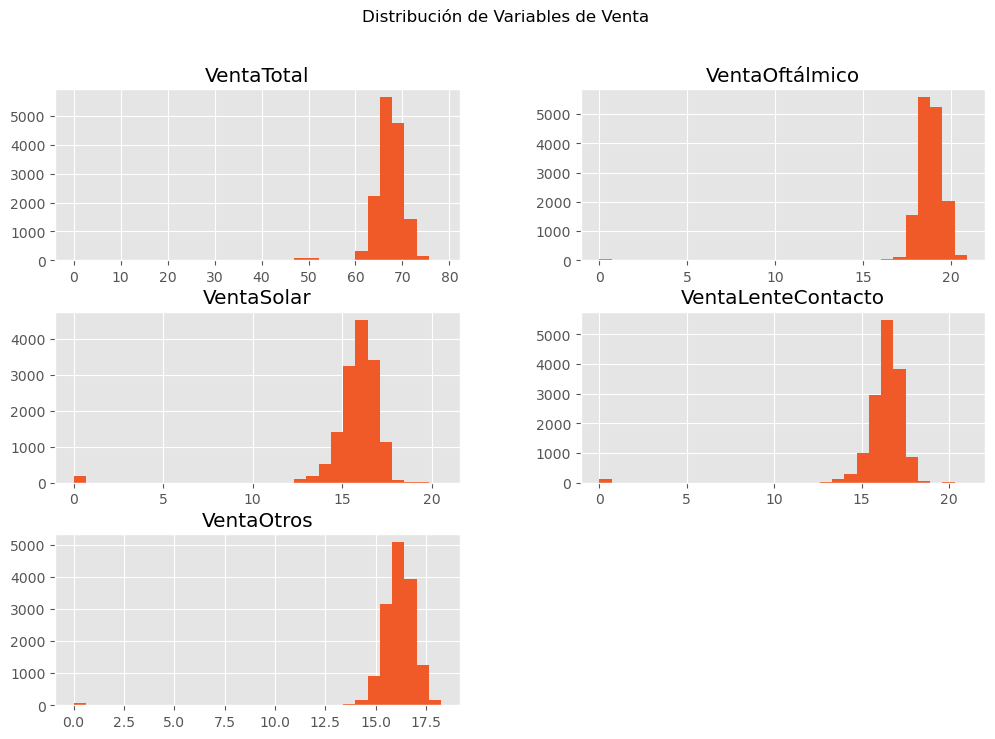

In [53]:
# Visualización de distribuciones

# Histogramas
df[ventas].hist(figsize = (12,8), bins = 30, color = '#F05A28')
plt.suptitle('Distribución de Variables de Venta')
plt.show()

### Análisis de distribución de variables de venta

Las distribuciones de las variables de venta muestran un comportamiento relativamente concentrado alrededor de sus medias, indicando estabilidad en el desempeño comercial de las sucursales de Más Visión durante el periodo analizado.

- VentaTotal

La variable VentaTotal presenta una distribución aproximadamente normal con concentración principal entre 65 y 72 unidades monetarias aproximadamente. Esto sugiere que la mayoría de las sucursales mantienen niveles de ventas consistentes. Sin embargo, también se observan algunos registros cercanos a cero, lo que podría indicar meses sin operación, sucursales con bajo desempeño o posibles anomalías operativas.

- VentaOftálmico

Las ventas oftálmicas muestran una distribución estrecha y estable, concentrándose principalmente entre 18 y 20.5. Esto indica que esta categoría mantiene un comportamiento homogéneo entre sucursales y probablemente representa una de las líneas de negocio más sólidas y constantes de la empresa.

- VentaSolar

La categoría solar presenta una dispersión ligeramente mayor en comparación con las demás variables. Las ventas se concentran alrededor de valores entre 15 y 17, aunque existen algunos registros inferiores y valores extremos cercanos a cero. Esto podría sugerir una sensibilidad mayor a factores estacionales o promocionales.

- VentaLenteContacto

Las ventas de lentes de contacto reflejan una distribución relativamente simétrica, concentrada entre 15.5 y 17.5. El comportamiento indica estabilidad comercial y baja variabilidad entre sucursales, aunque nuevamente se identifican algunos registros atípicos con valores muy bajos.

- VentaOtros

La categoría VentaOtros es una de las más compactas en términos de dispersión, mostrando ventas mayormente concentradas entre 15 y 17. Esto puede indicar una demanda más estable y predecible en productos complementarios.

Hallazgos generales: 

- La mayoría de las variables presentan distribuciones relativamente normales y concentradas, lo cual sugiere consistencia en las operaciones comerciales.
- Se identifican registros con ventas cercanas a cero en distintas categorías, los cuales podrían representar outliers o periodos sin actividad comercial.
- Las categorías presentan baja dispersión general, indicando un comportamiento relativamente homogéneo entre sucursales.
- VentaTotal parece estar altamente influenciada por el comportamiento conjunto de las categorías principales, especialmente VentaOftálmico y VentaSolar.
  
### Conclusión

El análisis de distribuciones evidencia que los datos presentan una estructura estable y consistente, adecuada para análisis posteriores de tendencias, correlaciones y modelado predictivo. Asimismo, la presencia de posibles valores atípicos justifica realizar análisis adicionales de outliers para comprender mejor el comportamiento extremo de ciertas sucursales o periodos específicos.

### Tendencias y patrones

In [47]:
# Ventas totales por año
ventas_anuales = df.groupby('año')['VentaTotal'].sum()

ventas_anuales

año
2022    319780.494601
2023    328574.630712
2024    344084.937955
Name: VentaTotal, dtype: float64

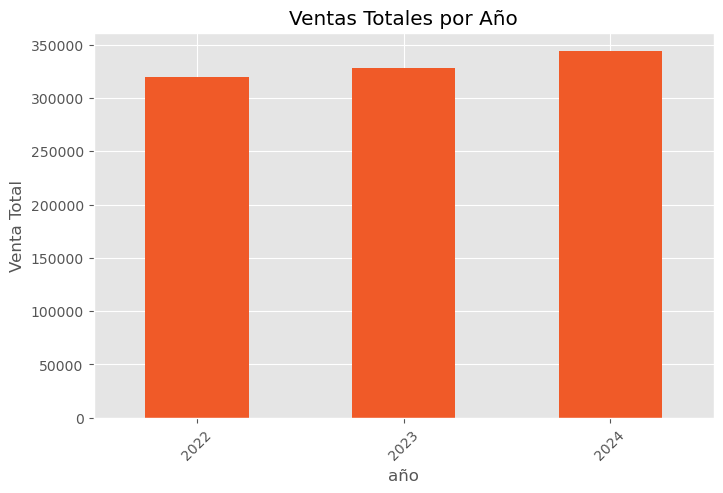

In [52]:
# Gráfico
ventas_anuales.plot(kind = 'bar', figsize = (8,5), color = '#F05A28')

plt.title('Ventas Totales por Año')
plt.ylabel('Venta Total')
plt.xticks(rotation = 45)
plt.show()

Las ventas totales muestran una tendencia de crecimiento sostenido entre 2022 y 2024. Se observa un incremento progresivo año con año, pasando de aproximadamente 319 mil en 2022 a más de 344 mil en 2024.

Este comportamiento sugiere una evolución positiva en el desempeño comercial de Más Visión, posiblemente impulsada por expansión operativa, estabilidad en la demanda y estrategias comerciales efectivas. Además, el crecimiento constante indica un comportamiento saludable y estable del negocio a lo largo del periodo analizado.

In [54]:
# Ventas por mes
ventas_mensuales = df.groupby('mes')['VentaTotal'].sum()

ventas_mensuales

mes
abril         82009.329443
agosto        82313.812227
diciembre     85512.187213
enero         81900.132596
febrero       81503.672726
julio         82659.475231
junio         82257.448278
marzo         82356.964569
mayo          82684.798607
noviembre     84612.251040
octubre       82716.330856
septiembre    81913.660482
Name: VentaTotal, dtype: float64

In [55]:
orden_meses = [
    'enero', 'febrero', 'marzo', 'abril',
    'mayo', 'junio', 'julio', 'agosto',
    'septiembre', 'octubre', 'noviembre', 'diciembre'
]

ventas_mensuales = ventas_mensuales.reindex(orden_meses)

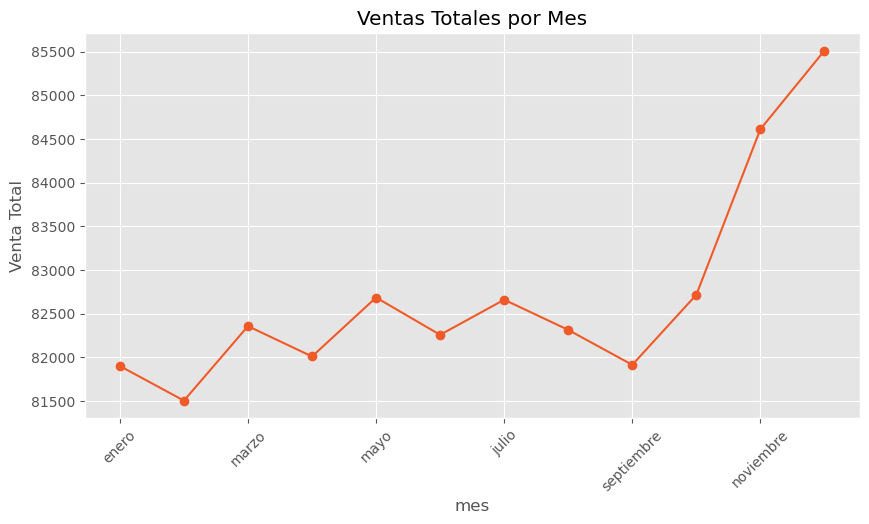

In [60]:
# Gráfico mensual
ventas_mensuales.plot(figsize = (10,5), marker = 'o', color = '#F05A28')

plt.title('Ventas Totales por Mes')
plt.ylabel('Venta Total')
plt.xticks(rotation = 45)
plt.show()

Las ventas mensuales muestran un comportamiento relativamente estable a lo largo del año, con ligeras variaciones entre meses. Sin embargo, destacan noviembre y diciembre como los periodos con mayores niveles de ventas, alcanzando aproximadamente 84 mil y 85 mil respectivamente.

Este patrón sugiere una posible estacionalidad positiva hacia el cierre del año, posiblemente influenciada por campañas promocionales, temporadas comerciales de alto consumo o incrementos en la demanda durante fechas festivas. Por otro lado, meses como febrero y enero presentan niveles ligeramente inferiores, aunque sin caídas significativas, lo que refleja estabilidad operativa en el negocio.

In [58]:
# Ventas por formato de tienda
ventas_formato = df.groupby('Formato')['VentaTotal'].mean()
ventas_formato

Formato
A    64.388286
B    50.673450
C    69.584257
D    66.813756
E    67.970593
F    65.662975
G    46.208411
Name: VentaTotal, dtype: float64

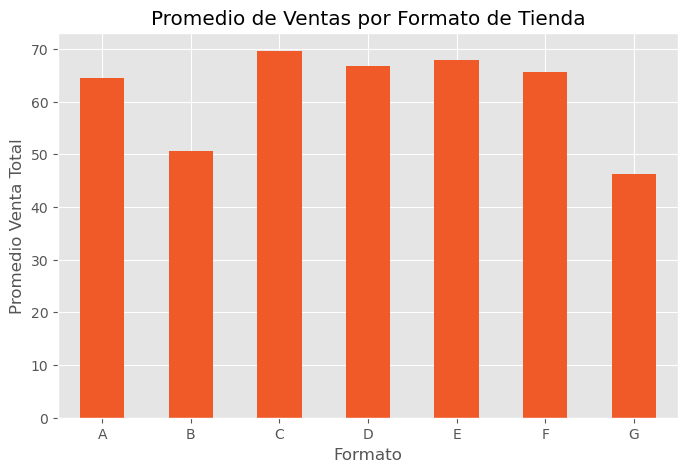

In [65]:
# Gráfico
ventas_formato.plot(kind = 'bar', figsize = (8,5), color = '#F05A28')

plt.title('Promedio de Ventas por Formato de Tienda')
plt.ylabel('Promedio Venta Total')
plt.xticks(rotation = 360)
plt.show()

El análisis por formato de tienda muestra diferencias relevantes en el desempeño comercial entre tipos de sucursal. El formato C presenta el mayor promedio de ventas, seguido por los formatos E y D, lo que indica un mejor rendimiento operativo y comercial en estas categorías.

Por otro lado, los formatos G y B registran los promedios más bajos, sugiriendo menor volumen de ventas o posibles limitaciones relacionadas con ubicación, tamaño de tienda o demanda. En general, los resultados evidencian que el formato de sucursal tiene un impacto importante sobre el comportamiento de las ventas totales.

### Detección de outliers

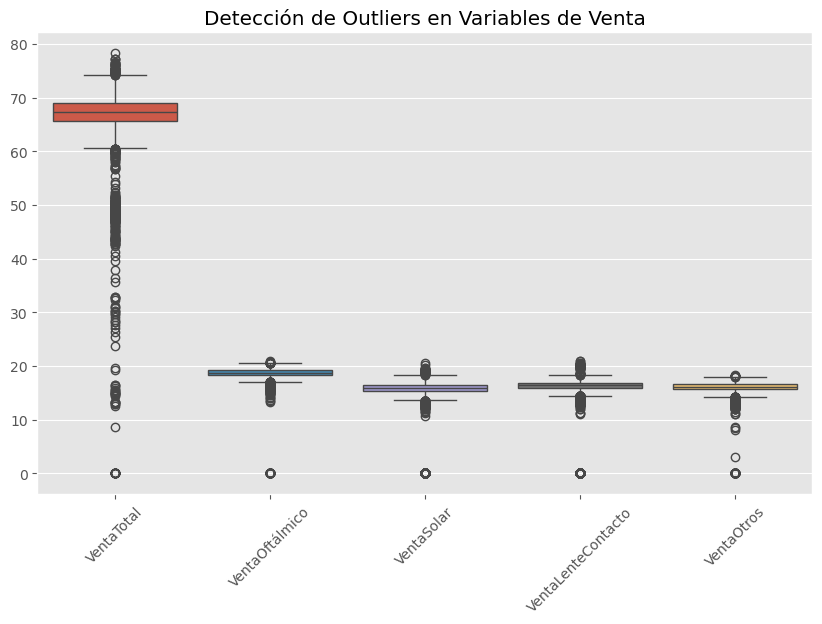

In [80]:
# Boxplot de ventas
plt.figure(figsize = (10,6))

sns.boxplot(data = df[ventas])

plt.title('Detección de Outliers en Variables de Venta')
plt.xticks(rotation = 45)
plt.show()

El análisis de outliers muestra que la mayoría de las variables de venta presentan una distribución relativamente estable y concentrada alrededor de sus medianas. Sin embargo, se identifican valores atípicos tanto superiores como inferiores en distintas categorías.

La variable VentaTotal es la que presenta mayor dispersión y cantidad de outliers, incluyendo registros extremadamente bajos e incluso valores cercanos a cero. Esto podría estar asociado a sucursales con bajo desempeño, periodos sin operación o comportamientos atípicos específicos.

En las categorías VentaOftálmico, VentaSolar, VentaLenteContacto y VentaOtros, los outliers son menos pronunciados, aunque también existen registros inferiores y superiores fuera del rango intercuartílico. Esto indica que, aunque el comportamiento general es homogéneo, ciertas sucursales o periodos presentan variaciones relevantes respecto al promedio.

En general, los resultados sugieren que el dataset mantiene una estabilidad operativa adecuada, pero contiene observaciones extremas que podrían influir en análisis estadísticos y modelos predictivos posteriores.

In [69]:
# Análisis por sucursal
ventas_sucursal = df.groupby('Id_suc')['VentaTotal'].mean()
ventas_sucursal.describe()

count    443.000000
mean      66.423644
std        4.564509
min       26.375217
25%       65.324849
50%       66.988443
75%       68.691992
max       75.612310
Name: VentaTotal, dtype: float64

El análisis de ventas promedio por sucursal muestra un comportamiento relativamente estable entre las 443 sucursales analizadas. La media de ventas se sitúa alrededor de 66.4, con una desviación estándar moderada de 4.56, lo que indica una variabilidad controlada en el desempeño comercial general.

La mayoría de las sucursales se concentran entre 65 y 69 en ventas promedio, reflejando consistencia operativa dentro de la red comercial. Sin embargo, se identifican sucursales con niveles considerablemente inferiores, alcanzando mínimos cercanos a 26, lo que podría indicar bajo rendimiento, diferencias operativas o condiciones particulares de mercado.

Asimismo, algunas sucursales alcanzan valores máximos superiores a 75, destacando como puntos de venta con desempeño sobresaliente dentro de la organización.

In [82]:
# Top sucursales
ventas_sucursal.sort_values(ascending = False).head(10)

Id_suc
254    75.612310
76     73.921171
37     73.185699
3      72.982762
263    72.718313
52     72.388651
71     72.386905
15     72.380646
277    72.365503
81     72.344907
Name: VentaTotal, dtype: float64

El análisis de las sucursales con mayor promedio de ventas evidencia que ciertos puntos de venta presentan un desempeño significativamente superior al promedio general de la red. La sucursal 254 lidera el ranking con un promedio de ventas cercano a 75.6, seguida por otras sucursales con valores superiores a 72.

Estos resultados sugieren la existencia de sucursales altamente eficientes o ubicadas en zonas con mayor demanda y tráfico comercial. Además, la concentración de ventas elevadas en determinados puntos podría representar oportunidades para identificar mejores prácticas operativas, estrategias comerciales exitosas o características de mercado que puedan replicarse en otras sucursales.

In [71]:
# Sucursales con menores ventas
ventas_sucursal.sort_values().head(10)

Id_suc
284    26.375217
257    34.987408
309    38.744768
305    43.831283
304    45.413035
443    46.208411
308    46.559574
301    48.303054
294    51.644334
307    52.605923
Name: VentaTotal, dtype: float64

El análisis de las sucursales con menores niveles de venta muestra una diferencia considerable respecto al promedio general de la empresa. La sucursal 284 presenta el desempeño más bajo, con un promedio cercano a 26.4, mientras que el resto de las sucursales con menor rendimiento se mantienen por debajo de 53.

Estas diferencias podrían estar relacionadas con factores como ubicación, menor flujo de clientes, tamaño de sucursal, condiciones del mercado local o limitaciones operativas. Asimismo, los resultados permiten identificar puntos de venta que podrían requerir estrategias de mejora, análisis más detallados o acciones comerciales específicas para incrementar su desempeño.

### Correlaciones

In [73]:
# Matriz de correlación
correlacion = df[[
    'VentaTotal',
    'VentaOftálmico',
    'VentaSolar',
    'VentaLenteContacto',
    'VentaOtros'
]].corr()

correlacion

,VentaTotal,VentaOftálmico,VentaSolar,VentaLenteContacto,VentaOtros
VentaTotal,1.000000,0.835137,0.768907,0.771072,0.854327
VentaOftálmico,0.835137,1.000000,0.499828,0.538064,0.789937
VentaSolar,0.768907,0.499828,1.000000,0.341267,0.504865
VentaLenteContacto,0.771072,0.538064,0.341267,1.000000,0.587062
VentaOtros,0.854327,0.789937,0.504865,0.587062,1.000000


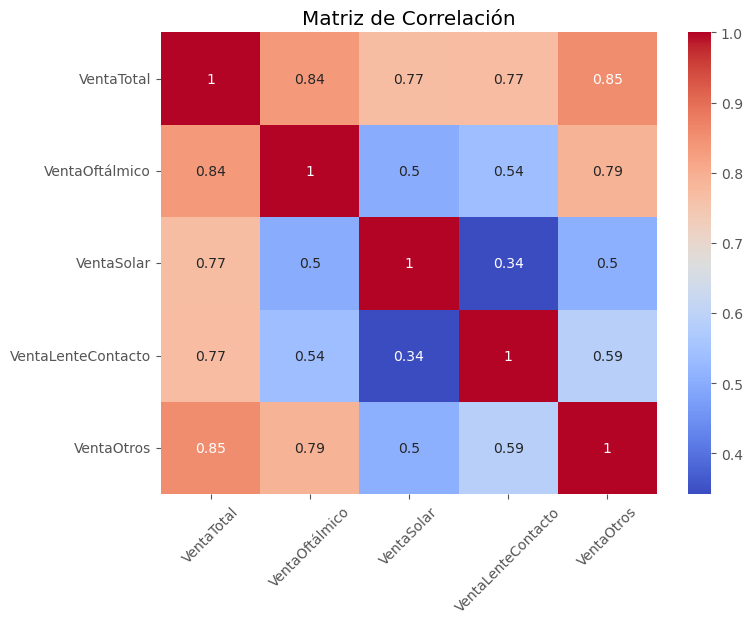

In [81]:
# Heatmap
plt.figure(figsize = (8,6))

sns.heatmap(correlacion, annot = True, cmap = 'coolwarm')

plt.title('Matriz de Correlación')
plt.xticks(rotation = 45)
plt.show()

La matriz de correlación muestra relaciones positivas entre todas las variables de venta, lo que indica que las categorías comerciales tienden a crecer de manera conjunta.

VentaTotal presenta una correlación alta con todas las categorías, destacando especialmente VentaOtros (0.85) y VentaOftálmico (0.83). Esto sugiere que estas líneas de negocio tienen una influencia importante sobre el desempeño total de ventas de Más Visión.

Asimismo, se observan correlaciones moderadas entre las distintas categorías individuales, lo que podría indicar comportamientos comerciales relacionados, aunque sin dependencia excesiva entre variables. La menor correlación se presenta entre VentaSolar y VentaLenteContacto (0.34), reflejando que ambas categorías podrían responder a dinámicas de consumo distintas.

En general, el análisis evidencia una estructura comercial coherente, donde el crecimiento de ciertas categorías impacta positivamente en las ventas totales de la empresa.

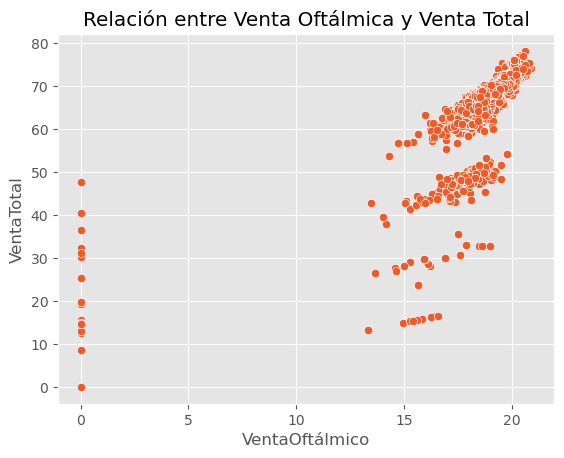

In [84]:
# Gráfico de dispersión
sns.scatterplot(
    data = df,
    x = 'VentaOftálmico',
    y = 'VentaTotal',
    color = '#F05A28'
)

plt.title('Relación entre Venta Oftálmica y Venta Total')
plt.show()

El gráfico de dispersión muestra una relación positiva clara entre VentaOftálmico y VentaTotal. A medida que aumentan las ventas oftálmicas, también se incrementan las ventas totales, lo que confirma una fuerte asociación entre ambas variables.

La concentración principal de puntos se encuentra entre valores de 17 a 21 en VentaOftálmico y entre 60 y 75 en VentaTotal, indicando que la categoría oftálmica representa una parte importante del desempeño comercial general de Más Visión.

Asimismo, se observan algunos registros atípicos con ventas oftálmicas cercanas a cero y niveles bajos de ventas totales, lo que podría estar relacionado con sucursales de bajo rendimiento, periodos sin actividad o posibles anomalías operativas.

En general, el comportamiento visual confirma los resultados observados previamente en la matriz de correlación, donde VentaOftálmico mostró una correlación alta con VentaTotal.

# Conclusión

El análisis exploratorio evidenció un comportamiento comercial estable y con tendencia positiva en las ventas totales de Más Visión durante el periodo analizado. Se identificó un crecimiento sostenido entre 2022 y 2024, así como patrones estacionales con incrementos relevantes en los últimos meses del año, posiblemente asociados a estrategias promocionales y mayor demanda comercial.

Asimismo, el análisis permitió detectar diferencias significativas en el desempeño entre formatos y sucursales, identificando tanto puntos de venta sobresalientes como sucursales con niveles de venta considerablemente inferiores al promedio. De igual forma, las correlaciones mostraron que categorías como VentaOftálmico y VentaOtros tienen una fuerte influencia sobre las ventas totales de la compañía.

Finalmente, la limpieza, transformación y enriquecimiento de los datos permitió consolidar un dataset robusto, consistente y preparado para las siguientes etapas del proyecto, facilitando futuros análisis visuales y el desarrollo de modelos predictivos con mayor confiabilidad.

## Guardar en CSV

In [85]:
# Guardar dataset limpio en CSV
df.to_csv('MasVision_EDA_Limpio.csv', index = False)

## Guardar en Excel

In [86]:
# Guardar dataset limpio en Excel
df.to_excel('MasVision_EDA_Limpio.xlsx', index = False)

## Verificar archivos guardados

In [87]:
import os

os.listdir()

['.anaconda',
 '.conda',
 '.condarc',
 '.continuum',
 '.dbus-keyrings',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.mamba',
 '.matplotlib',
 '.ms-ad',
 '.python_history',
 '.VirtualBox',
 '.virtual_documents',
 '1. Distribuciones de Probabilidad (2).ipynb',
 '2. Teorema del Limite central.ipynb',
 '3. Contraste de Hipotesis.ipynb',
 '3D Objects',
 'Amazon.xlsx',
 'anaconda3',
 'anaconda_projects',
 'AppData',
 'Application Data',
 'apps.csv',
 'arbol_gini.pdf',
 'arbol_gini.png',
 'Base.db',
 'Breast-cancer.csv',
 'cell_samples.csv',
 'Clientes.db',
 'Clientes.sql',
 'ClientesVarios.db',
 'co2-mm-mlo_csv.csv',
 'Configuración local',
 'Contacts',
 'Cookies',
 'Customers.csv',
 'Customers1.csv',
 'Customers2.csv',
 'Customers3.csv',
 'data_description.txt',
 'Datos de programa',
 'deals.csv',
 'Desktop',
 'diabetes.csv',
 'DIM_CALENDAR (2).xlsx',
 'DIM_CATEGORY (2).csv',
 'DIM_PRODUCT (1).xlsx',
 'DIM_SEGMENT (1).xlsx',
 'Distribución de Unidades Vendidas por Categoría esc. 500.

Finalmente, el dataset limpio y enriquecido fue exportado en formatos .csv y .xlsx para facilitar su reutilización en etapas posteriores del proyecto, incluyendo visualización de datos y desarrollo de modelos predictivos.

El archivo final incluye:

- Variables originales de ventas.
- Columnas de descuentos mensuales.
- Variables temporales.
- Transformaciones realizadas durante el proceso de limpieza y preparación de datos.